# Factor Bar Chart and Timeseries Figures

In [1]:
import numpy as np
import seaborn as sns
import joblib
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
import matplotlib.dates as mdates
import matplotlib.ticker as mticker
from matplotlib.ticker import FuncFormatter

In [2]:
# force the math text to look normal
mpl.rcParams['mathtext.default'] = 'regular'

def major_ticks(x, pos=None):
    """Set the major ticks according
    to this custom style
    """
    x = mdates.num2date(x)
    if pos == 0:
        fmt = "%-d\n%b %Y\n%I %p"
    else:
        fmt = "%-d"
    return x.strftime(fmt)

# set the default seaborn params
sns.set("paper", "ticks", color_codes=True, palette='colorblind')

## Loading Data

In [3]:
#load in the comp data
comp = pd.read_csv('4_factor_resid.csv')
comp.rename(columns={'Unnamed: 0':'species'},inplace=True)
comp

,species,Factor 1,Factor 2,Factor 3,Factor 4,Residual
0,co,0.535692,0.077552,0.356172,0.019285,0.011298
1,no,0.542956,0.007190,0.436357,0.015076,-0.001579
2,no2,0.943543,0.047231,0.000000,0.009373,-0.000146
3,o3,0.408316,0.030088,0.557316,0.004565,-0.000284
4,bin0,0.131454,0.736866,0.131495,0.000000,0.000186
5,bin1,0.000000,0.824934,0.000000,0.268548,-0.093482
6,bin2,0.000000,0.535046,0.000000,0.491062,-0.026109
7,bin3,0.065536,0.236188,0.055757,0.641437,0.001083
8,bin4,0.107049,0.028244,0.227858,0.634248,0.002601
9,bin5,0.070676,0.000000,0.277484,0.654333,-0.002494


In [4]:
comp2 = pd.melt(comp,id_vars='species', value_vars=['Factor 1','Factor 2','Factor 3','Factor 4','Residual'])
comp2

,species,variable,value
0,co,Factor 1,0.535692
1,no,Factor 1,0.542956
2,no2,Factor 1,0.943543
3,o3,Factor 1,0.408316
4,bin0,Factor 1,0.131454
5,bin1,Factor 1,0.000000
6,bin2,Factor 1,0.000000
7,bin3,Factor 1,0.065536
8,bin4,Factor 1,0.107049
9,bin5,Factor 1,0.070676


In [6]:
#load in the timeseries data
ts = pd.read_csv('MOD-000689_timeseries_hourly_scaled.csv').reset_index()
results = pd.read_csv('4_factor_results.csv')

ts = pd.concat([ts,results['Factor 1'],results['Factor 2'], results['Factor 3'], results['Factor 4']], axis = 1)
cols_reordered = ['timestamp_local','bin0','bin1','bin2','bin3','bin4','bin5','co','o3','no','no2','Factor 1','Factor 2','Factor 3','Factor 4']
ts = ts[cols_reordered]
ts.head()

,timestamp_local,bin0,bin1,bin2,bin3,bin4,bin5,co,o3,no,no2,Factor 1,Factor 2,Factor 3,Factor 4
0,2025-08-07 03:00:00,0.233847,0.075159,0.038911,0.032895,0.025510,0.023256,0.089636,0.514708,0.006620,0.271859,0.029791,0.060124,0.084739,0.008821
1,2025-08-07 04:00:00,0.232046,0.074671,0.040208,0.026316,0.025510,0.023256,0.091651,0.475879,0.007079,0.244864,0.026371,0.060469,0.079114,0.008020
2,2025-08-07 05:00:00,0.207041,0.061981,0.033722,0.032895,0.030612,0.029070,0.097077,0.410642,0.007308,0.337076,0.038773,0.052930,0.053645,0.012049
3,2025-08-07 06:00:00,0.345669,0.120059,0.059663,0.052632,0.045918,0.040698,0.106060,0.413126,0.007041,0.496656,0.055508,0.094763,0.033777,0.020803
4,2025-08-07 07:00:00,0.861772,0.391898,0.172503,0.111842,0.081633,0.063953,0.196275,0.496666,0.010293,0.468944,0.038064,0.257959,0.051018,0.047260


In [7]:
ts['timestamp_local'] = pd.to_datetime(ts['timestamp_local']) #convert timestamp column to pandas timestamp format
ts = ts.set_index('timestamp_local',append=False) #setindex as local time
ts

,bin0,bin1,bin2,bin3,bin4,bin5,co,o3,no,no2,Factor 1,Factor 2,Factor 3,Factor 4
timestamp_local,,,,,,,,,,,,,,
2025-08-07 03:00:00,0.233847,0.075159,0.038911,0.032895,0.025510,0.023256,0.089636,0.514708,0.006620,0.271859,0.029791,0.060124,0.084739,0.008821
2025-08-07 04:00:00,0.232046,0.074671,0.040208,0.026316,0.025510,0.023256,0.091651,0.475879,0.007079,0.244864,0.026371,0.060469,0.079114,0.008020
2025-08-07 05:00:00,0.207041,0.061981,0.033722,0.032895,0.030612,0.029070,0.097077,0.410642,0.007308,0.337076,0.038773,0.052930,0.053645,0.012049
2025-08-07 06:00:00,0.345669,0.120059,0.059663,0.052632,0.045918,0.040698,0.106060,0.413126,0.007041,0.496656,0.055508,0.094763,0.033777,0.020803
2025-08-07 07:00:00,0.861772,0.391898,0.172503,0.111842,0.081633,0.063953,0.196275,0.496666,0.010293,0.468944,0.038064,0.257959,0.051018,0.047260
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-12-31 14:00:00,0.147229,0.028795,0.023346,0.019737,0.015306,0.005814,0.086822,0.604785,0.007729,0.672241,0.083808,0.029839,0.058806,0.001054
2025-12-31 15:00:00,0.141428,0.029283,0.023346,0.019737,0.015306,0.005814,0.089836,0.596941,0.007423,0.674391,0.084212,0.028428,0.056841,0.001564
2025-12-31 16:00:00,0.157031,0.033675,0.027237,0.019737,0.015306,0.011628,0.090700,0.571839,0.009298,0.686574,0.085342,0.033406,0.049513,0.002746


In [8]:
#taking daily average of ts. round to floor of the day
ts = ts.reset_index()

ts_day = ts.groupby(ts['timestamp_local'].dt.floor('d')).agg(bin0 = ('bin0','mean'),
                                                  bin1 = ('bin1','mean'),
                                                  bin2 = ('bin2','mean'),
                                                  bin3 = ('bin3','mean'),
                                                  bin4 = ('bin4','mean'),
                                                  bin5 = ('bin5','mean'),
                                                  co = ('co','mean'),
                                                  o3 = ('o3','mean'),
                                                  no = ('no','mean'),
                                                  no2 = ('no2','mean'),
                                                  factor1 = ('Factor 1','mean'),
                                                  factor2 = ('Factor 2','mean'),
                                                  factor3 = ('Factor 3','mean'),
                                                  factor4 = ('Factor 4','mean')).reset_index()

ts_day = ts_day.set_index('timestamp_local')
ts_day.head()

,bin0,bin1,bin2,bin3,bin4,bin5,co,o3,no,no2,factor1,factor2,factor3,factor4
timestamp_local,,,,,,,,,,,,,,
2025-08-07,0.436925,0.143322,0.064295,0.046679,0.040573,0.030731,0.111158,0.604860,0.008994,0.355516,0.035531,0.119173,0.093617,0.013421
2025-08-08,0.125450,0.027351,0.019509,0.022204,0.023384,0.020591,0.088364,0.595154,0.009215,0.291527,0.035280,0.024747,0.102161,0.006093
2025-08-09,0.183895,0.040569,0.024103,0.022752,0.022747,0.017442,0.094072,0.641642,0.009896,0.346642,0.041077,0.040960,0.105765,0.003874
2025-08-10,0.269962,0.058057,0.027670,0.022752,0.021259,0.015746,0.097067,0.739775,0.010749,0.420628,0.048670,0.063692,0.118648,0.002412
2025-08-11,0.431453,0.102225,0.040856,0.031250,0.028912,0.022287,0.098320,0.695036,0.010119,0.559723,0.062518,0.111553,0.090248,0.003459


## Setting Up Barchart and 6-month Figures

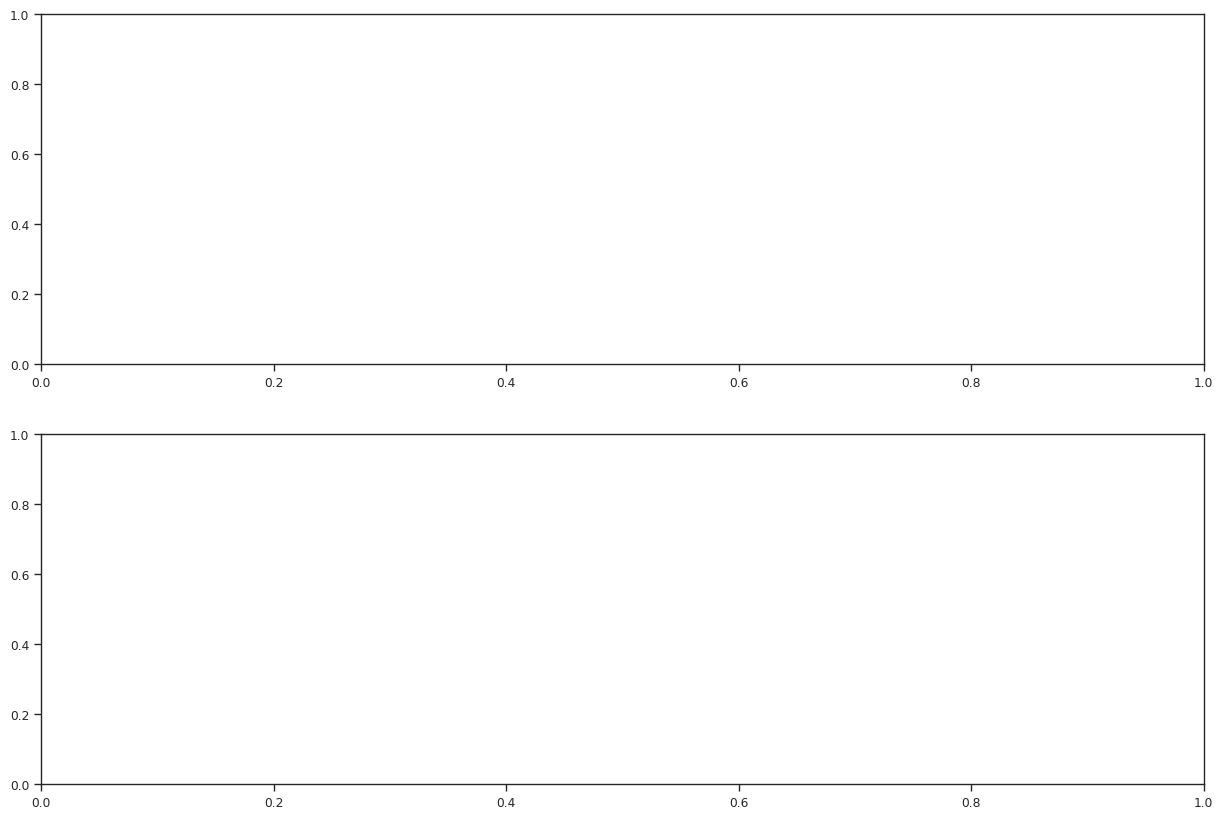

In [41]:
# set up the figure
fig = plt.figure(figsize=(15, 10))

ax1 = fig.add_subplot(211)
ax2 = fig.add_subplot(212)

In [42]:
cols = ['bin0', 'bin1', 'bin2','bin3','bin4','bin5','co', 'o3','no', 'no2']

pal = sns.color_palette()

colors = [pal[3], pal[2], pal[4], pal[5]]
colors += sns.color_palette("Blues", 6)
colors.reverse()

In [43]:
ax1 = sns.barplot(x='variable',y='value',
        data=comp2,
        ax=ax1, hue='species',hue_order=cols,
        palette=colors, saturation=1, edgecolor='black', linewidth=0.25,
        errwidth=.75)

/tmp/ipython-input-1035/2976516543.py:1: FutureWarning: 

The `errwidth` parameter is deprecated. And will be removed in v0.15.0. Pass `err_kws={'linewidth': 0.75}` instead.

  ax1 = sns.barplot(x='variable',y='value',


In [44]:
ax1.set_ylim(-0.2, 1)
ax1.set_xlabel("")
ax1.set_ylabel("Percent of Species Signal\nDescribed by Factor", fontsize=14)
ax1.set(yticks=np.linspace(-0.2, 1, 13), yticklabels=["","","0","","","","","50","","","","","100"])
ax1.tick_params(axis='both', which='major', labelsize=14)
ax1.axhline(y=0, color='black', linestyle='-', lw =0.5)

In [45]:
handles, _ = ax1.get_legend_handles_labels()
labels = ["Bin 0", "Bin 1", "Bin 2", "Bin 3","Bin 4","Bin 5","CO","$O_3$","$NO$", "$NO_2$"]
ax1.legend(handles, labels)

In [46]:
ax2.plot(ts_day.index, ts_day["factor1"], label="Factor 1 ", lw=1, color=sns.xkcd_rgb['slate blue'])
ax2.plot(ts_day.index, ts_day["factor2"], label="Factor 2", lw=1, color=sns.xkcd_rgb['dull green'])
ax2.plot(ts_day.index, ts_day["factor3"], label="Factor 3", lw=1, color=sns.xkcd_rgb['dark lavender'])
ax2.plot(ts_day.index, ts_day["factor4"], label="Factor 4", lw=1, color=sns.xkcd_rgb['faded red'])

ax2.set_ylabel("Factor Intensity (a.u.)", fontsize=14)

n_days = min(180, len(ts_day))

ax2.set_xlim(ts_day.index[-n_days], ts_day.index[-1])
#ax2.set_xlim(ts_day.index[0], ts_day.index[-1])

ax2.legend(loc='upper right',fontsize=10)
ax2.tick_params(axis='both', which='major', labelsize=14)

In [47]:
ax1.set_title('(a)',fontsize=14)
ax2.set_title('(b)',fontsize=14)

Text(0.5, 1.0, '(b)')

In [48]:
plt.gcf().text(0.09, 0.9, "(a)", fontsize=12)
plt.gcf().text(0.5, 0.9, "(b)", fontsize=12)
plt.gcf().text(0.09,0.9,'MOD-00689',fontsize=12)

plt.tight_layout()

<Figure size 640x480 with 0 Axes>

In [49]:
fig.savefig('time_barchart_MOD-000689_4_factor.png')

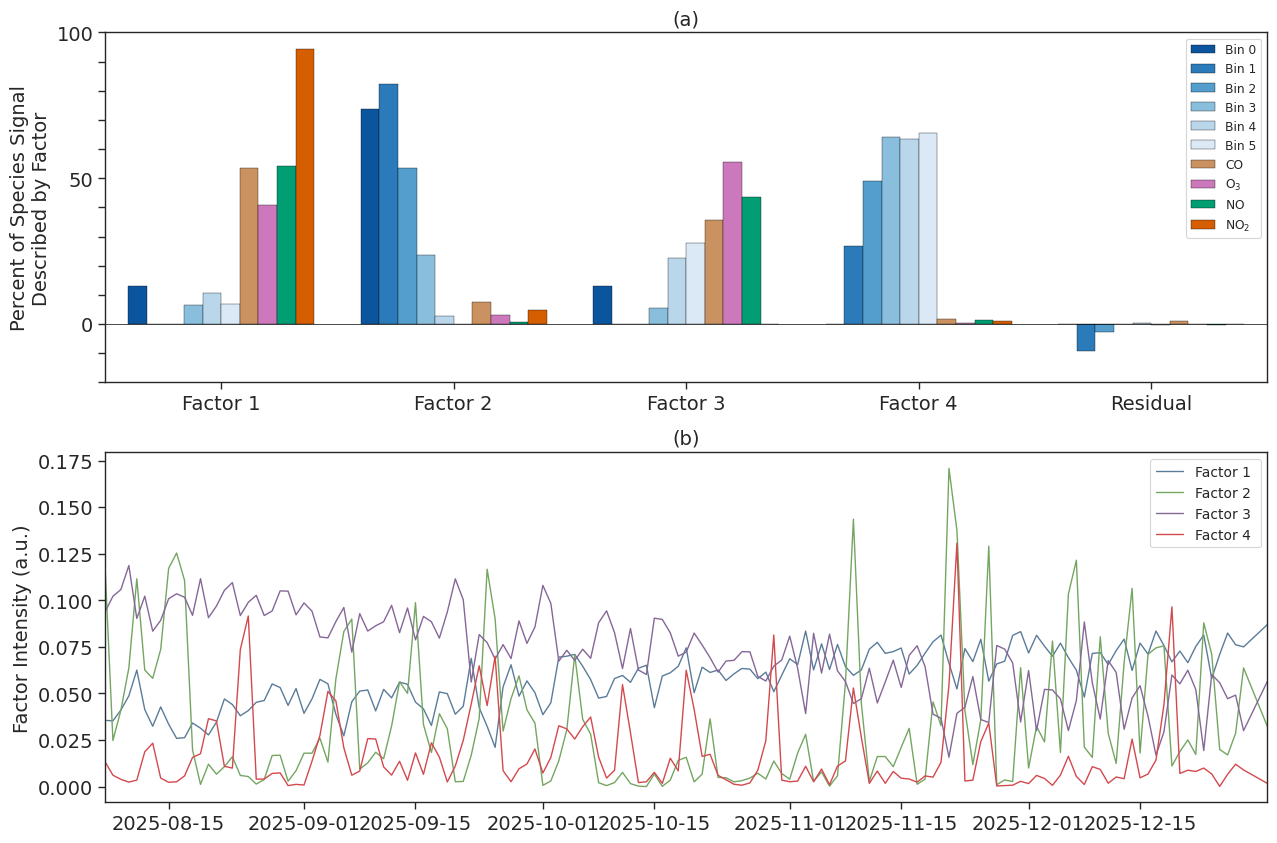

In [50]:
fig

## Setting Up Diurnal Figure

In [51]:
ts.head()

,bin0,bin1,bin2,bin3,bin4,bin5,co,o3,no,no2,Factor 1,Factor 2,Factor 3,Factor 4,Hour
timestamp_local,,,,,,,,,,,,,,,
2025-08-07 03:00:00,0.233847,0.075159,0.038911,0.032895,0.025510,0.023256,0.089636,0.514708,0.006620,0.271859,0.029791,0.060124,0.084739,0.008821,3
2025-08-07 04:00:00,0.232046,0.074671,0.040208,0.026316,0.025510,0.023256,0.091651,0.475879,0.007079,0.244864,0.026371,0.060469,0.079114,0.008020,4
2025-08-07 05:00:00,0.207041,0.061981,0.033722,0.032895,0.030612,0.029070,0.097077,0.410642,0.007308,0.337076,0.038773,0.052930,0.053645,0.012049,5
2025-08-07 06:00:00,0.345669,0.120059,0.059663,0.052632,0.045918,0.040698,0.106060,0.413126,0.007041,0.496656,0.055508,0.094763,0.033777,0.020803,6
2025-08-07 07:00:00,0.861772,0.391898,0.172503,0.111842,0.081633,0.063953,0.196275,0.496666,0.010293,0.468944,0.038064,0.257959,0.051018,0.047260,7


In [52]:
#prepping data
ts = ts.set_index('timestamp_local')
ts['Hour'] = ts.index.hour
ts.head()

KeyError: "None of ['timestamp_local'] are in the columns"

In [22]:
#groupping by hour and calculate the mean
diurnal_data = ts.groupby('Hour')[['Factor 1','Factor 2','Factor 3','Factor 4']].mean()
diurnal_data.index = diurnal_data.index.map(lambda x: "{:02d}:00".format(x))
diurnal_data

,Factor 1,Factor 2,Factor 3,Factor 4
Hour,,,,
00:00,0.060348,0.036453,0.065985,0.019981
01:00,0.058759,0.037270,0.064988,0.017072
02:00,0.058770,0.037207,0.063579,0.017143
03:00,0.058990,0.038573,0.061142,0.018161
04:00,0.058975,0.039541,0.059846,0.015544
05:00,0.060809,0.041075,0.054440,0.016987
06:00,0.063277,0.043245,0.047997,0.019719
07:00,0.063751,0.043252,0.048565,0.022955
08:00,0.056929,0.040653,0.057465,0.017308


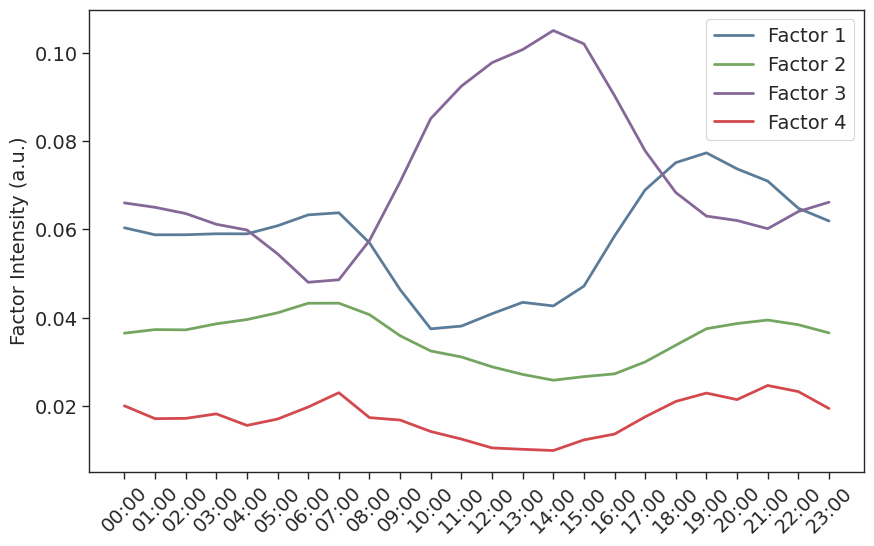

In [24]:
# set up the figure
plt.figure(figsize=(10, 6))

plt.plot(diurnal_data.index, diurnal_data['Factor 1'], label='Factor 1', lw = 2, color=sns.xkcd_rgb['slate blue'])
plt.plot(diurnal_data.index, diurnal_data['Factor 2'], label='Factor 2', lw = 2, color=sns.xkcd_rgb['dull green'])
plt.plot(diurnal_data.index, diurnal_data['Factor 3'], label='Factor 3', lw = 2, color=sns.xkcd_rgb['dark lavender'])
plt.plot(diurnal_data.index, diurnal_data['Factor 4'], label='Factor 4', lw = 2, color=sns.xkcd_rgb['faded red'])

plt.ylabel('Factor Intensity (a.u.)', fontsize = 14)
plt.legend(loc='upper right',fontsize=14)
plt.xticks(range(0, 24))
plt.xticks(rotation=45)

plt.tick_params(labelsize=14)

plt.savefig('diurnal_MOD-000689_4_factor.png')
plt.show()